In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df = pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [3]:
df.shape

(3554, 18)

In [4]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,signature global park 4,sector 36,0.82,7586.0,3.0,2.0,2,2.0,New Property,850.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0
1,flat,smart world gems,sector 89,0.95,8597.0,2.0,2.0,2,4.0,New Property,1226.0,1.0,1.0,0.0,0.0,0.0,0.0,38.0
2,flat,breez global hill view,sohna road,0.32,5470.0,2.0,2.0,1,17.0,New Property,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,49.0
3,flat,bestech park view sanskruti,sector 92,1.60,8020.0,3.0,4.0,3+,10.0,Relatively New,1615.0,0.0,1.0,0.0,0.0,1.0,1.0,174.0
4,flat,suncity avenue,sector 102,0.48,9023.0,2.0,2.0,1,5.0,Relatively New,582.0,0.0,0.0,1.0,0.0,0.0,0.0,159.0


In [5]:
latlong = pd.read_csv('latlong.csv')

In [6]:
latlong

,sector,coordinates
0,sector 1,"28.3663° N, 76.9456° E"
1,sector 2,"28.5095° N, 77.0320° E"
2,sector 3,"28.4909° N, 77.0176° E"
3,sector 4,"28.4738° N, 77.0107° E"
4,sector 5,"28.4794° N, 77.0176° E"
...,...,...
124,sector 113,"28.5287° N, 77.0233° E"
125,sector 114,"28.5334° N, 77.0118° E"
126,sector 115,"28.5385° N, 77.0061° E"
127,gwal pahari,"28.4484° N, 77.0210° E"


In [7]:
latlong['latitude'] = latlong['coordinates'].str.split(',').str.get(0).str.split('°').str.get(0).astype('float')

In [8]:
latlong['longitude'] = latlong['coordinates'].str.split(',').str.get(1).str.split('°').str.get(0).astype('float')

In [9]:
latlong.head()

,sector,coordinates,latitude,longitude
0,sector 1,"28.3663° N, 76.9456° E",28.3663,76.9456
1,sector 2,"28.5095° N, 77.0320° E",28.5095,77.0320
2,sector 3,"28.4909° N, 77.0176° E",28.4909,77.0176
3,sector 4,"28.4738° N, 77.0107° E",28.4738,77.0107
4,sector 5,"28.4794° N, 77.0176° E",28.4794,77.0176


In [10]:
new_df = df.merge(latlong, on='sector')

In [11]:
new_df.columns

Index(['property_type', 'society', 'sector', 'price', 'price_per_sqft',
       'bedRoom', 'bathroom', 'balcony', 'floorNum', 'agePossession',
       'built_up_area', 'study room', 'servant room', 'store room',
       'pooja room', 'others', 'furnishing_type', 'luxury_score',
       'coordinates', 'latitude', 'longitude'],
      dtype='object')

In [12]:
group_df = new_df.groupby('sector')[
    ['price','price_per_sqft','built_up_area','latitude','longitude']
].mean()

In [13]:
group_df

,price,price_per_sqft,built_up_area,latitude,longitude
sector,,,,,
gwal pahari,3.192222,9585.777778,3056.166667,28.4484,77.0210
manesar,0.962258,4608.064516,2027.367742,28.3515,76.9428
sector 1,1.860000,8249.833333,2327.833333,28.3663,76.9456
sector 10,2.092857,11866.571429,1908.857143,28.4537,77.0009
sector 102,1.696636,10603.822430,1556.130841,28.4750,76.9715
...,...,...,...,...,...
sector 91,1.648235,7586.117647,2028.647059,28.4014,76.9225
sector 92,0.934000,5928.290000,1571.341800,28.4079,76.9153
sector 93,0.848889,8009.888889,1017.000000,28.4153,76.9326


In [14]:
fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',
                  color_continuous_scale=px.colors.cyclical.IceFire, zoom=10,
                  mapbox_style="open-street-map",text=group_df.index)
fig.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5820\860414701.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(group_df, lat="latitude", lon="longitude", color="price_per_sqft", size='built_up_area',


In [15]:
new_df.to_csv('data_viz1.csv',index=False)

In [16]:
df1 = pd.read_csv('gurgaon_properties.csv')

In [17]:
df1.head()

,property_name,property_type,society,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,additionalRoom,address,floorNum,facing,agePossession,nearbyLocations,description,furnishDetails,features,rating
0,3 BHK Flat in Sultanpur,flat,empire estate,3.50,16666.0,2100.0,Super Built up area 2100(195.1 sq.m.),3,3,2,servant room,"Sultanpur, Gurgaon, Haryana",3.0,North-West,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Sanatan Dharm M...",Empire estate is one of the most popular desti...,"['3 Wardrobe', '6 Fan', '1 Exhaust Fan', '1 Mo...","['Water purifier', 'Security / Fire Alarm', 'F...",NaN
1,4 Bedroom House for sale in Nirvana Country,house,unitech espace,7.35,41762.0,1760.0,Plot area 240(200.67 sq.m.),4,4,3+,"pooja room,servant room","Nirvana Country, Gurgaon, Haryana",3.0,South,5 to 10 Year Old,"['Radhakrishna Shani Mandir', 'Sri Radhe Krish...",This is property is next to park and sunfacing.,"['5 Wardrobe', '1 Exhaust Fan', '4 Geyser', '9...","['High Ceiling Height', 'Maintenance Staff', '...","['Environment5 out of 5', 'Lifestyle5 out of 5..."
2,2 BHK Flat in Sector 89 Gurgaon,flat,smart world gems,1.00,9007.0,1110.0,Carpet area: 1110 (103.12 sq.m.),2,2,3,"study room,others","O-101c, Sector 89 Gurgaon, Gurgaon, Haryana",3.0,NaN,0 to 1 Year Old,"['Sant Soordas Sihi Metro Station', 'Airia Mal...","New property,near dwaraka expressway,near by a...",[],"['Security / Fire Alarm', 'Feng Shui / Vaastu ...","['Environment4 out of 5', 'Lifestyle4 out of 5..."
3,2 BHK Flat in Sector 71 Gurgaon,flat,signature andour heights,0.59,8428.0,700.0,Super Built up area 700(65.03 sq.m.)Built Up a...,2,2,1,not available,"001, Sector 71 Gurgaon, Gurgaon, Haryana",6.0,North-East,5 to 10 Year Old,"['Bigbasket SPR 5K DS', 'iON Digital Zone, DPG...",This is 2bhk semi furnished flat available on ...,"['1 Fan', '1 Exhaust Fan', '1 Geyser', '1 Ligh...","['Feng Shui / Vaastu Compliant', 'Security / F...","['Green Area5 out of 5', 'Construction4.5 out ..."
4,2 BHK Flat in Sector 81 Gurgaon,flat,signature global synera,0.50,6802.0,735.0,Super Built up area 735(68.28 sq.m.)Built Up a...,2,2,3,not available,"Ddd, Sector 81 Gurgaon, Gurgaon, Haryana",6.0,South,1 to 5 Year Old,"['Sapphire 83 Mall', 'Delhi Jaipur Expressway'...",This lovely 2 bhk apartment/flat in sector 81 ...,NaN,"['Security / Fire Alarm', 'Power Back-up', 'Fe...","['Green Area4 out of 5', 'Construction3 out of..."


In [18]:
wordcloud_df = df1.merge(df, left_index=True, right_index=True)[['features','sector']]

In [19]:
wordcloud_df.head()

,features,sector
0,"['Water purifier', 'Security / Fire Alarm', 'F...",sector 36
1,"['High Ceiling Height', 'Maintenance Staff', '...",sector 89
2,"['Security / Fire Alarm', 'Feng Shui / Vaastu ...",sohna road
3,"['Feng Shui / Vaastu Compliant', 'Security / F...",sector 92
4,"['Security / Fire Alarm', 'Power Back-up', 'Fe...",sector 102


In [20]:
import ast
main = []
for item in wordcloud_df['features'].dropna().apply(ast.literal_eval):
    main.extend(item)

In [21]:
main

['Water purifier',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Intercom Facility',
 'Lift(s)',
 'High Ceiling Height',
 'Maintenance Staff',
 'False Ceiling Lighting',
 'Water Storage',
 'Separate entry for servant room',
 'No open drainage around',
 'Bank Attached Property',
 'Piped-gas',
 'Internet/wi-fi connectivity',
 'Recently Renovated',
 'Visitor Parking',
 'Swimming Pool',
 'Park',
 'Security Personnel',
 'Natural Light',
 'Airy Rooms',
 'Spacious Interiors',
 'Low Density Society',
 'Waste Disposal',
 'Rain Water Harvesting',
 'Water softening plant',
 'Shopping Centre',
 'Fitness Centre / GYM',
 'Club house / Community Center',
 'High Ceiling Height',
 'Maintenance Staff',
 'Swimming Pool',
 'Separate entry for servant room',
 'Visitor Parking',
 'Fitness Centre / GYM',
 'Rain Water Harvesting',
 'Security / Fire Alarm',
 'Feng Shui / Vaastu Compliant',
 'Private Garden / Terrace',
 'Lift(s)',
 'Maintenance Staff',
 'Water Storage

In [22]:
from wordcloud import WordCloud

In [23]:
feature_text = ' '.join(main)

In [24]:
import pickle
pickle.dump(feature_text, open('feature_text.pkl','wb'))

In [25]:
feature_text

'Water purifier Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Intercom Facility Lift(s) High Ceiling Height Maintenance Staff False Ceiling Lighting Water Storage Separate entry for servant room No open drainage around Bank Attached Property Piped-gas Internet/wi-fi connectivity Recently Renovated Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Spacious Interiors Low Density Society Waste Disposal Rain Water Harvesting Water softening plant Shopping Centre Fitness Centre / GYM Club house / Community Center High Ceiling Height Maintenance Staff Swimming Pool Separate entry for servant room Visitor Parking Fitness Centre / GYM Rain Water Harvesting Security / Fire Alarm Feng Shui / Vaastu Compliant Private Garden / Terrace Lift(s) Maintenance Staff Water Storage No open drainage around Piped-gas Visitor Parking Swimming Pool Park Security Personnel Natural Light Airy Rooms Shopping Centre Fitness Centre / GYM Waste Disposal Clu

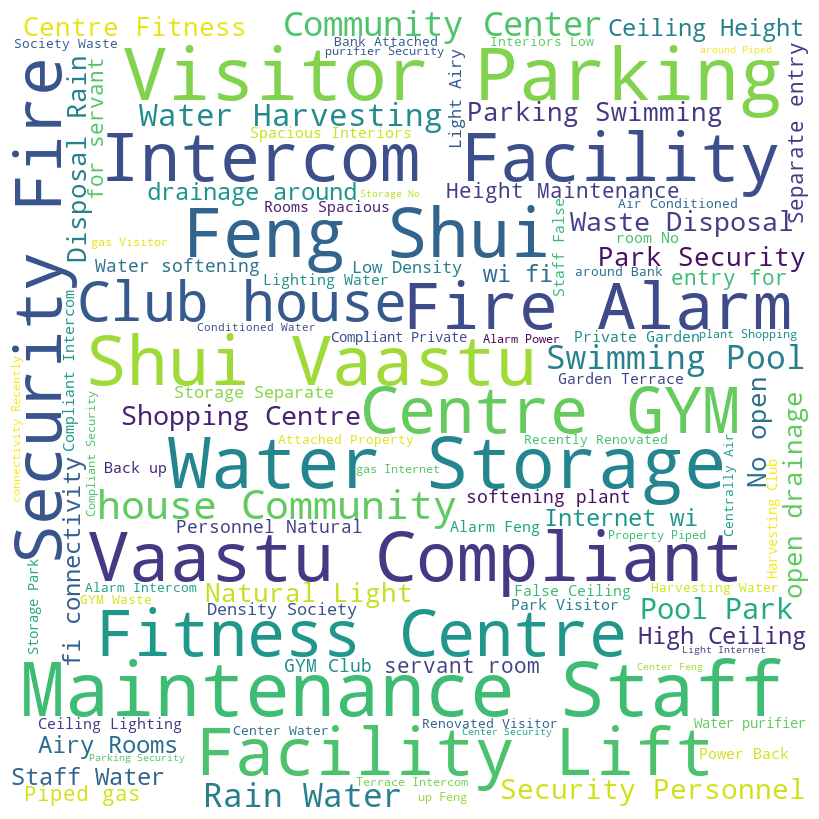

In [26]:
plt.rcParams["font.family"] = "Arial"

wordcloud = WordCloud(width = 800, height = 800, 
                      background_color ='white', 
                      stopwords = set(['s']),  # Any stopwords you'd like to exclude
                      min_font_size = 10).generate(feature_text)

plt.figure(figsize = (8, 8), facecolor = None) 
plt.imshow(wordcloud, interpolation='bilinear') 
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.show() # st.pyplot()

In [27]:
data = dict(
    names=["A", "B", "C", "D", "E", "F"],
    parents=["", "", "", "A", "A", "C"],
    values=[10, 20, 30, 40, 50, 60],
)

fig = px.sunburst(
    df1,
    names='property_type',
    values='price_per_sqft',
    parents='bedRoom',
    title="Sample Sunburst Chart"
)
fig.show()

In [28]:
fig = px.scatter(df, x="built_up_area", y="price", color="bedRoom", title="Area Vs Price")

# Show the plot
fig.show()

In [29]:
fig = px.pie(df, names='bedRoom', title='Total Bill Amount by Day')

# Show the plot
fig.show()

In [30]:
temp_df = df[df['bedRoom'] <= 4]
# Create side-by-side boxplots of the total bill amounts by day
fig = px.box(temp_df, x='bedRoom', y='price', title='BHK Price Range')

# Show the plot
fig.show()


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5820\3761596323.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'house']['price'])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_5820\3761596323.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[df['property_type'] == 'fl

<Axes: xlabel='price', ylabel='Density'>

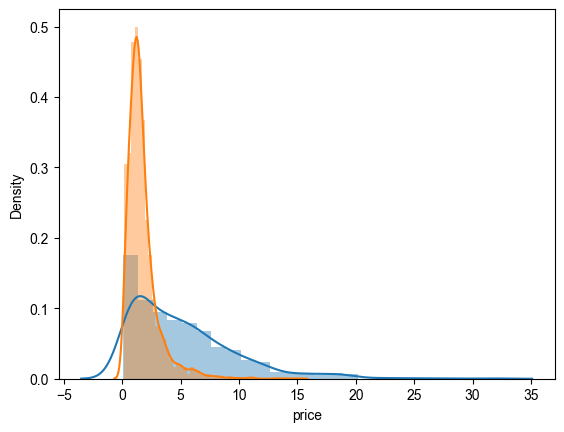

In [31]:
sns.distplot(df[df['property_type'] == 'house']['price'])
sns.distplot(df[df['property_type'] == 'flat']['price'])

In [32]:
new_df['sector'].unique().tolist().insert(0,'overall')